In [70]:
import pandas as pd

In [71]:
df = pd.read_csv("../Output/data for gentrification classification.csv")

In [72]:
df.count()

LSOA21CD                    4994
delta_property_sales        4994
pct_minority_ethnic_2011    4994
pct_minority_ethnic_2021    4994
delta_minority_ethnic       4994
pct_owner_occupied_2011     4994
pct_owner_occupied_2021     4994
delta_owner_occupied        4994
pct_social_rented_2011      4994
pct_social_rented_2021      4994
delta_social_rented         4994
pct_private_rented_2011     4994
pct_private_rented_2021     4994
delta_private_rented        4994
pct_renters_2011            4994
pct_renters_2021            4994
delta_renters               4994
pct_high_education_2011     4994
pct_high_education_2021     4994
delta_high_education        4994
pct_high_sec_2011           4994
pct_high_sec_2021           4994
delta_high_sec              4994
pct_low_sec_2011            4994
pct_low_sec_2021            4994
delta_low_sec               4994
pct_professional_2011       4994
pct_professional_2021       4994
delta_professional          4994
pct_low_skill_2011          4994
pct_low_sk

In [73]:
def classify_gentrification_final_5(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
                'delta_property_sales', 
                'pct_minority_ethnic_2011', 'pct_minority_ethnic_2021', 'delta_minority_ethnic',
                'pct_professional_2011', 'pct_professional_2021', 'delta_professional', 
                'pct_owner_occupied_2011', 'pct_owner_occupied_2021', 'delta_owner_occupied',
                'pct_social_rented_2011', 'pct_social_rented_2021', 'delta_social_rented',
                'pct_private_rented_2011', 'pct_private_rented_2021', 'delta_private_rented',
                'pct_renters_2011', 'pct_renters_2021', 'delta_renters',
                'pct_high_education_2011','pct_high_education_2021','delta_high_education',
                'pct_low_skill_2011', 'pct_low_skill_2021', 'delta_low_skill',
                'pct_high_sec_2011', 'pct_high_sec_2021', 'delta_high_sec',
                'pct_low_sec_2011', 'pct_low_sec_2021', 'delta_low_sec'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
        # Class 0: Affluent and Middle Class

        if row['pct_low_sec_2021'] <  1.25 * q['pct_low_sec_2021'][0.5]:         # This step is try to find the alternatives to low-income population classification standard. 
            affluent_conditions = [                                               # Since London has a higher proportion of professional occupations than the whole UK, so i use the coefficient 1.25.
                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.5],
                row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5],
                
            ]
            if sum(affluent_conditions) >= 1:
                df.at[idx, 'gentrification_class'] = 'Class 0 - Stable Affluent and Moderate-income'
                continue

        # Class 4: Ongoing Gentrification
        vulnerable_2011 = [
            row['pct_high_education_2011'] < q['pct_high_education_2011'][0.5],
            row['pct_renters_2011'] > q['pct_renters_2011'][0.5],
            row['pct_minority_ethnic_2011'] > q['pct_minority_ethnic_2011'][0.5],
        ]
        hot_market_2011_2021 = [
            row['delta_property_sales'] > q['delta_property_sales'][0.5],
            row['delta_renters'] > q['delta_renters'][0.5]
        ]
        demographic_change = [
            row['delta_high_education'] > q['delta_high_education'][0.5],
            row['delta_professional'] > q['delta_professional'][0.5],
            row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
        ]
        if sum(vulnerable_2011) >= 2 and sum(hot_market_2011_2021) >= 1 and sum(demographic_change) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 4 - Ongoing Gentrification'
            continue

        # Class 2: Ongoing Displacement
        if row['delta_low_sec'] < 0 and (sum(vulnerable_2011) + sum(hot_market_2011_2021) + sum(demographic_change)) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 2 - Ongoing Displacement'
            continue

        # Class 3: At risk of gentrification
        vulnerable_2021 = [
            row['pct_high_education_2021'] < q['pct_high_education_2021'][0.5],
            row['pct_renters_2021'] > q['pct_renters_2021'][0.5],
            row['pct_minority_ethnic_2021'] > q['pct_minority_ethnic_2021'][0.5],
        ]
        if sum(vulnerable_2021) >= 2 and sum(hot_market_2011_2021) >= 1:
            df.at[idx, 'gentrification_class'] = 'Class 3 - At Risk of Gentrification'
            continue

        # Class 1: Stable Low-income
        df.at[idx, 'gentrification_class'] = 'Class 1 - Stable Low-income'

    return df[['LSOA21CD', 'gentrification_class']]

In [74]:
def classify_gentrification_final_7(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
                'delta_property_sales', 
                'pct_minority_ethnic_2011', 'pct_minority_ethnic_2021', 'delta_minority_ethnic',
                'pct_professional_2011', 'pct_professional_2021', 'delta_professional', 
                'pct_owner_occupied_2011', 'pct_owner_occupied_2021', 'delta_owner_occupied',
                'pct_social_rented_2011', 'pct_social_rented_2021', 'delta_social_rented',
                'pct_private_rented_2011', 'pct_private_rented_2021', 'delta_private_rented',
                'pct_renters_2011', 'pct_renters_2021', 'delta_renters',
                'pct_high_education_2011','pct_high_education_2021','delta_high_education',
                'pct_low_skill_2011', 'pct_low_skill_2021', 'delta_low_skill',
                'pct_high_sec_2011', 'pct_high_sec_2021', 'delta_high_sec',
                'pct_low_sec_2011', 'pct_low_sec_2021', 'delta_low_sec'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
            
        # Determining whether a region is affluent in 2011                             
        affluent_2011 = False                                                                  # This step is try to find the alternatives to low-income population classification standard.
        if row['pct_low_sec_2011'] < 1.25 * q['pct_low_sec_2011'][0.5]:                        # Since London has a higher proportion of professional occupations than the whole UK, so i use the coefficient 1.25.
            affluent_conditions_2011 = [
                row['pct_owner_occupied_2011'] > q['pct_owner_occupied_2011'][0.5],
                row['pct_social_rented_2011'] < q['pct_social_rented_2011'][0.5],
            ]
            if sum(affluent_conditions_2011) >= 1:
                affluent_2011 = True

        # Determining whether a region is affluent in 2021
        affluent_2021 = False
        if row['pct_low_sec_2021'] < 1.25 * q['pct_low_sec_2021'][0.5]:
            affluent_conditions_2021 = [
                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.5],
                row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5],
            ]
            if sum(affluent_conditions_2021) >= 1:
                affluent_2021 = True
        
        if affluent_2021:

            if affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 0 - Stable Affluent and Moderate-income'
            elif not affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 1 - Upgrading or Gentrified'
            continue

        if not affluent_2021:

            if affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 3 - Economically Decline'
                continue
        # Class 4: Ongoing Gentrification
            vulnerable_2011 = [
                row['pct_high_education_2011'] < q['pct_high_education_2011'][0.5],
                row['pct_renters_2011'] > q['pct_renters_2011'][0.5],
                row['pct_minority_ethnic_2011'] > q['pct_minority_ethnic_2011'][0.5],
            ]
            hot_market_2011_2021 = [
                row['delta_property_sales'] > q['delta_property_sales'][0.5],
                row['delta_renters'] > q['delta_renters'][0.5]
            ]
            demographic_change = [
                row['delta_high_education'] > q['delta_high_education'][0.5],
                row['delta_professional'] > q['delta_professional'][0.5],
                row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
            ]
            if sum(vulnerable_2011) >= 2 and sum(hot_market_2011_2021) >= 1 and sum(demographic_change) >= 2:
                df.at[idx, 'gentrification_class'] = 'Class 6 - Ongoing Gentrification'
                continue

            # Class 2: Ongoing Displacement
            if row['delta_low_sec'] < 0 and (sum(vulnerable_2011) + sum(hot_market_2011_2021) + sum(demographic_change)) >= 2:
                df.at[idx, 'gentrification_class'] = 'Class 4 - Ongoing Displacement'
                continue

            # Class 3: At risk of gentrification
            vulnerable_2021 = [
                row['pct_high_education_2021'] < q['pct_high_education_2021'][0.5],
                row['pct_renters_2021'] > q['pct_renters_2021'][0.5],
                row['pct_minority_ethnic_2021'] > q['pct_minority_ethnic_2021'][0.5],
            ]
            if sum(vulnerable_2021) >= 2 and sum(hot_market_2011_2021) >= 1:
                df.at[idx, 'gentrification_class'] = 'Class 5 - At Risk of Gentrification'
                continue

            # Class 1: Stable Low-income
            df.at[idx, 'gentrification_class'] = 'Class 2 - Stable Low-income'

    return df[['LSOA21CD', 'gentrification_class']]

In [75]:
df_5 = classify_gentrification_final_5(df)
df_7 = classify_gentrification_final_7(df)

In [76]:
df_5['gentrification_class'].value_counts()

gentrification_class
Class 0 - Stable Affluent and Moderate-income    2534
Class 3 - At Risk of Gentrification               721
Class 1 - Stable Low-income                       639
Class 4 - Ongoing Gentrification                  562
Class 2 - Ongoing Displacement                    538
Name: count, dtype: int64

In [77]:
df_7['gentrification_class'].value_counts()

gentrification_class
Class 0 - Stable Affluent and Moderate-income    2318
Class 5 - At Risk of Gentrification               643
Class 2 - Stable Low-income                       581
Class 6 - Ongoing Gentrification                  549
Class 4 - Ongoing Displacement                    530
Class 1 - Upgrading or Gentrified                 216
Class 3 - Economically Decline                    157
Name: count, dtype: int64

In [78]:
df_5[['LSOA21CD', 'gentrification_class']].to_csv("../Output/Gentrification label_2021_5class.csv", index=False)
df_7[['LSOA21CD', 'gentrification_class']].to_csv("../Output/Gentrification label_2021_7class.csv", index=False)

C:\Users\wbwha\AppData\Local\Temp\ipykernel_23452\3551050732.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_5_clean, x='Count', y='Description', ax=axes[0], palette=palette)
C:\Users\wbwha\AppData\Local\Temp\ipykernel_23452\3551050732.py:63: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=class_5_clean, x='Count', y='Description', ax=axes[0], palette=palette)
C:\Users\wbwha\AppData\Local\Temp\ipykernel_23452\3551050732.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_7_clean, x='Count', y='Description', ax=axes[1], palette=palette)
C:\Users\wbwha\AppData\Local\Temp\ipykernel_23452\3551050732.py

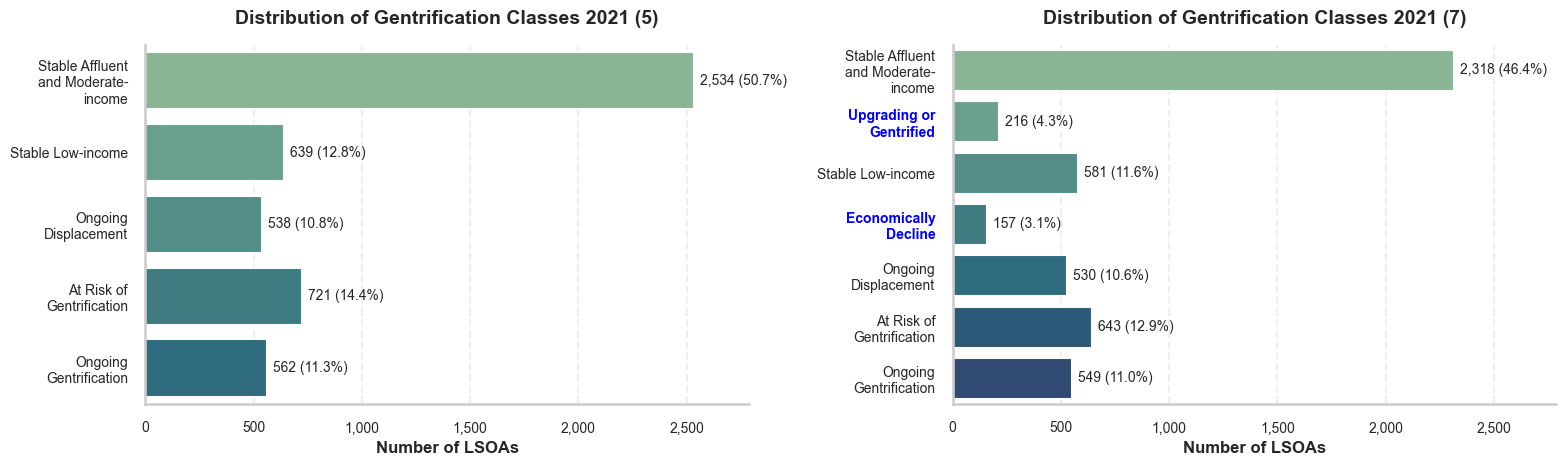

In [79]:
import re

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import textwrap

sns.set_theme(style="whitegrid", context="talk")

def prepare_counts_with_desc(df):
    """
    Prepare counts:
    - Count each gentrification_class
    - Keep full class string for sorting
    - Extract description after '-'
    - Sort by numeric class ID if available
    - Compute percentage
    """
    counts = df['gentrification_class'].value_counts(dropna=False).reset_index()
    counts.columns = ['Class', 'Count']

    # Replace NaN with 'NaN'
    counts['Class'] = counts['Class'].astype('object').where(counts['Class'].notna(), 'NaN')

    # Extract description after '-'
    def extract_desc(s):
        if s == 'NaN':
            return 'NaN'
        parts = re.split(r'\s*-\s*', str(s), maxsplit=1)
        return parts[1] if len(parts) > 1 else s
    counts['Description'] = counts['Class'].apply(extract_desc)

    # Sort by numeric class ID if possible
    def to_num_or_nan(x):
        try:
            m = re.search(r'\d+', str(x))
            return float(m.group()) if m else np.nan
        except:
            return np.nan
    counts['_num'] = counts['Class'].map(to_num_or_nan)
    counts = counts.sort_values(by=['_num', 'Class'], na_position='last').drop(columns=['_num'])

    # Percentage
    total = counts['Count'].sum()
    counts['Percent'] = counts['Count'] / total

    return counts

# Prepare data
class_5_clean = prepare_counts_with_desc(df_5)
class_7_clean = prepare_counts_with_desc(df_7)

# Shared x-axis limit
xmax = max(class_5_clean['Count'].max(), class_7_clean['Count'].max()) * 1.10

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
palette = sns.color_palette("crest", n_colors=max(len(class_5_clean), len(class_7_clean)))

# Left plot
sns.barplot(data=class_5_clean, x='Count', y='Description', ax=axes[0], palette=palette)
axes[0].set_title('Distribution of Gentrification Classes 2021 (5)',fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Number of LSOAs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xlim(0, xmax)

# Right plot
sns.barplot(data=class_7_clean, x='Count', y='Description', ax=axes[1], palette=palette)
axes[1].set_title('Distribution of Gentrification Classes 2021 (7)',fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Number of LSOAs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlim(0, xmax)

# Format x-axis numbers
fmt_thousand = FuncFormatter(lambda x, p: f'{int(x):,}')
for ax in axes:
    sns.despine(ax=ax, left=False, bottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(fmt_thousand)
    ax.tick_params(axis='both', labelsize=10)


# Auto-wrap y-axis labels
def wrap_labels(ax, width=15):
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)

wrap_labels(axes[0], width=18)
wrap_labels(axes[1], width=18)

# Find y-labels that are different between the two datasets
desc_5 = set(class_5_clean['Description'])
desc_7 = set(class_7_clean['Description'])
diff_labels = desc_5.symmetric_difference(desc_7)  # labels present in only one set

# Color them blue in the plots
for ax in axes:
    for label in ax.get_yticklabels():
        if label.get_text().replace("\n", " ") in diff_labels:
            label.set_color("blue")
            label.set_fontweight("bold")

# Annotate counts + percent to the right of bars
def annotate_bars(ax, df):
    for i, (cnt, pct) in enumerate(zip(df['Count'], df['Percent'])):
        ax.text(cnt + xmax * 0.01, i, f"{cnt:,} ({pct*100:.1f}%)",
                va='center', ha='left', fontsize=10)

annotate_bars(axes[0], class_5_clean)
annotate_bars(axes[1], class_7_clean)

plt.tight_layout()
plt.show()

In [80]:
import geopandas as gpd

# Load LSOA boundary
gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp")

In [81]:
# Merge classification results
gdf_5 = gdf.merge(df_5[['LSOA21CD', 'gentrification_class']], left_on='LSOA21CD',right_on='LSOA21CD', how='left')
gdf_7 = gdf.merge(df_7[['LSOA21CD', 'gentrification_class']], left_on='LSOA21CD',right_on='LSOA21CD', how='left')

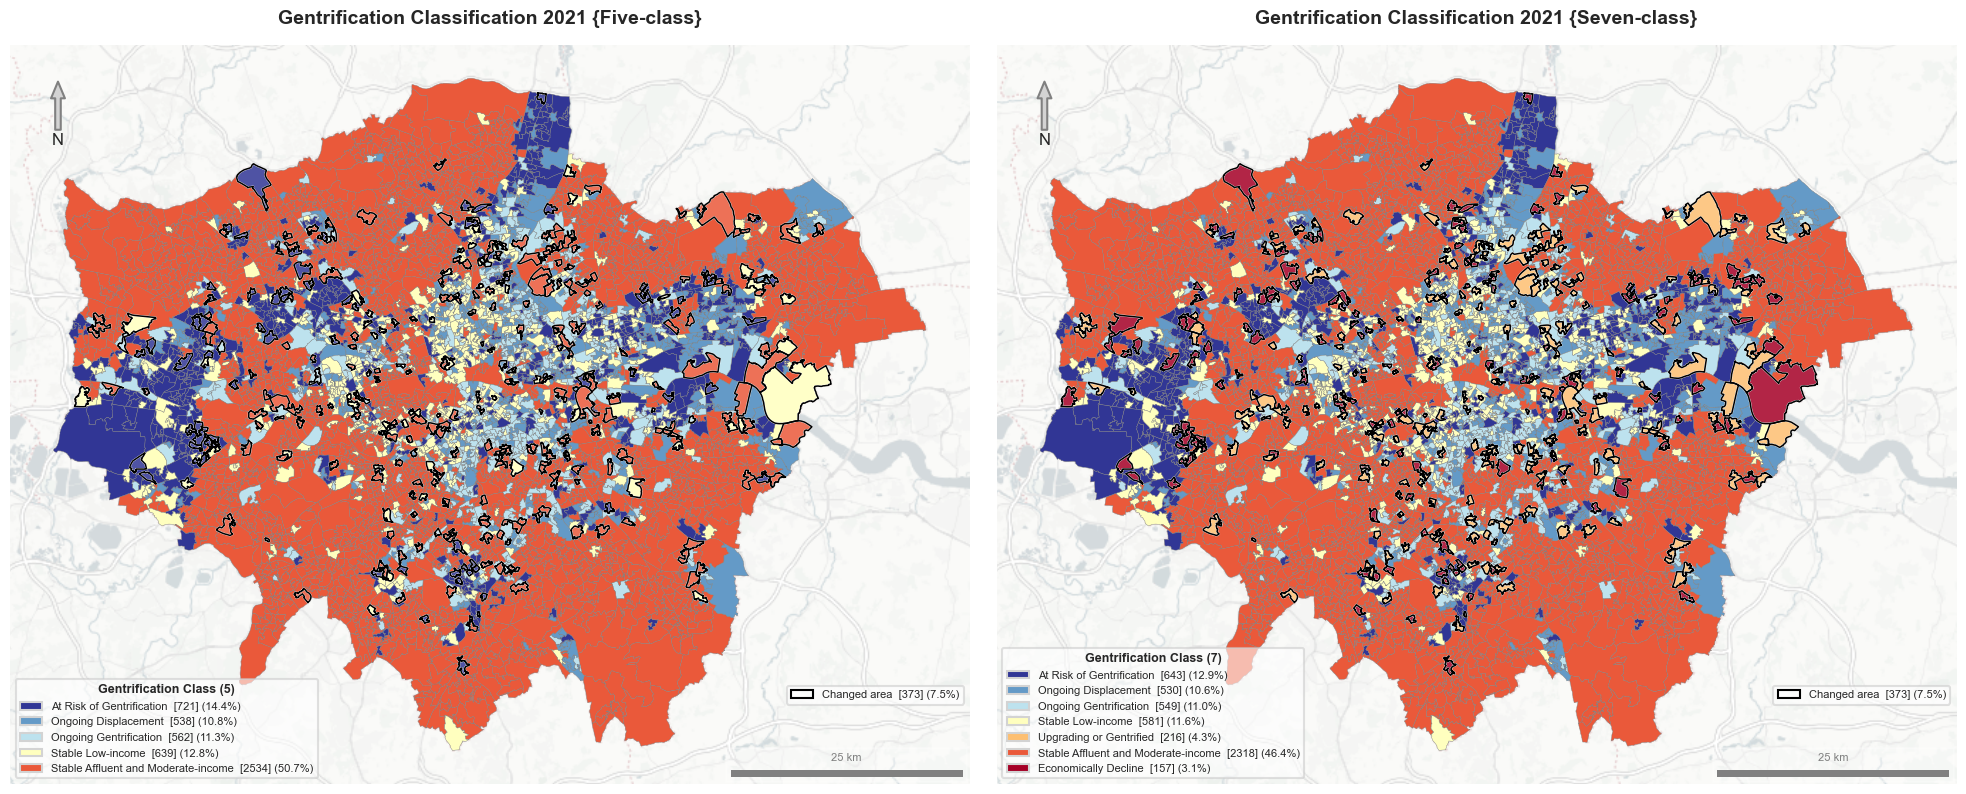

In [82]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar

import contextily as ctx

# -----------------------
# Helpers
# -----------------------
def extract_after_dash(s: str) -> str:
    """Use the text after the first '-' as the semantic label."""
    if not isinstance(s, str):
        s = str(s)
    parts = s.split('-', 1)
    return parts[1].strip() if len(parts) > 1 else s.strip()

def wrap_label(s, width=26):
    """Wrap long legend labels for readability."""
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def build_label_color_map(labels_in_order, cmap_name="RdYlBu_r"):
    """Return dict: label -> color using a discrete, ordered palette."""
    K = len(labels_in_order)
    base = plt.get_cmap(cmap_name, K)
    return {lab: base(i) for i, lab in enumerate(labels_in_order)}

def wrap_label(s, width=26):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def plot_categorical_map(
    ax,
    gdf_web,
    label_col,
    label2color,
    title,
    legend_title="Class (after '-')",
    highlight_gdf=None,
    highlight_color=(1, 1, 1, 0.25),
    show_percent_base="non-missing"
):
    # Prepare discrete colormap in fixed order
    ordered = list(label2color.keys())
    lab2idx = {lab: i for i, lab in enumerate(ordered)}
    g = gdf_web.copy()
    g["__idx__"] = g[label_col].map(lab2idx)
    cmap = ListedColormap([label2color[lab] for lab in ordered])

    # Base thematic map
    g.plot(
        ax=ax,
        column="__idx__",
        cmap=cmap,
        linewidth=0.3,
        edgecolor="grey",
        legend=False
    )

    # Highlight overlay
    if highlight_gdf is not None and not highlight_gdf.empty:
        highlight_gdf.plot(ax=ax, facecolor=highlight_color, edgecolor='none', zorder=7)
        highlight_gdf.boundary.plot(ax=ax, color='white', linewidth=1.5, zorder=8)
        highlight_gdf.boundary.plot(ax=ax, color="#000000", linewidth=1.1, zorder=9)

    # Title / axes
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")

    # Denominator for percentages
    denom = g[label_col].notna().sum() if show_percent_base == "non-missing" else len(g)

    # --- Legend 1: main categories ---
    counts = g[label_col].value_counts(dropna=False)
    cat_handles = []
    for lab in ordered:
        cnt = int(counts.get(lab, 0))
        pct = (cnt / denom * 100.0) if denom > 0 else 0.0
        label_txt = f"{lab}  [{cnt}] ({pct:.1f}%)"
        cat_handles.append(Patch(facecolor=label2color[lab], edgecolor="lightgrey", label=label_txt))

    leg1 = ax.legend(
        handles=cat_handles,
        title=legend_title,
        fontsize=8,
        title_fontsize=9,
        loc="lower left",
        frameon=True
    )
    leg1.get_frame().set_alpha(0.6)
    leg1.get_title().set_fontweight('bold')

    ax.add_artist(leg1)  # keep the first legend when adding a second one

    # --- Legend 2: changed area ---
    if highlight_gdf is not None and not highlight_gdf.empty:
        changed_cnt = len(highlight_gdf)
        changed_pct = (changed_cnt / len(g)) * 100.0 if len(g) > 0 else 0.0
        changed_label = f"Changed area  [{changed_cnt}] ({changed_pct:.1f}%)"
        changed_patch = Patch(facecolor=highlight_color, edgecolor="#000000", label=changed_label)
        leg2 = ax.legend(
            handles=[changed_patch],
            fontsize=8,
            loc="lower right",  # you can choose another location
            bbox_to_anchor=(1, 0.1),
            frameon=True
        )
        leg2.get_frame().set_alpha(0.6)


# -----------------------
# Reproject & extract labels (use text after '-')
# -----------------------
gdf5_web = gdf_5.to_crs(epsg=3857).copy()
gdf7_web = gdf_7.to_crs(epsg=3857).copy()
gdf5_web["label_after"] = gdf5_web["gentrification_class"].astype(str).apply(extract_after_dash)
gdf7_web["label_after"] = gdf7_web["gentrification_class"].astype(str).apply(extract_after_dash)

# -----------------------
# Detect changed areas by ID (replace 'LSOA21CD' with your own ID column if different)
# -----------------------
merged = gdf5_web[['LSOA21CD', 'label_after', 'geometry']].merge(
    gdf7_web[['LSOA21CD', 'label_after']],
    on='LSOA21CD', suffixes=('_5', '_7')
)
changed_ids = merged.loc[merged['label_after_5'] != merged['label_after_7'], 'LSOA21CD']
changed_gdf_5 = gdf5_web[gdf5_web['LSOA21CD'].isin(changed_ids)]
changed_gdf_7 = gdf7_web[gdf7_web['LSOA21CD'].isin(changed_ids)]

# -----------------------
# Build 7-class master palette (based on text after '-'), and 5-class subset
# -----------------------
seven_labels = pd.unique(gdf7_web["label_after"].dropna())
label2color_7 = build_label_color_map(seven_labels, cmap_name="RdYlBu_r")

five_labels_all = pd.unique(gdf5_web["label_after"].dropna())
missing_in_master = [lab for lab in five_labels_all if lab not in label2color_7]
if missing_in_master:
    print("[WARN] Some five-class labels not present in seven-class master palette:", missing_in_master)

five_labels = [lab for lab in five_labels_all if lab in label2color_7]
label2color_5 = {lab: label2color_7[lab] for lab in five_labels}

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor="white")
for ax in axes:
    ax.set_facecolor("#f7f7f7")  # subtle neutral background

# Basemap (Carto Light, no labels) via URL (works across contextily versions)
carto_light_url = "https://cartodb-basemaps-a.global.ssl.fastly.net/light_nolabels/{z}/{x}/{y}{r}.png"
basemap_alpha = 1.0  # 0.3–0.7 recommended

# North arrow placement (axis coords)
nx, ny, nlen = 0.05, 0.95, 0.08

# Left: five-class with translucent change mask
ax = axes[0]
plot_categorical_map(ax, gdf5_web, "label_after", label2color_5,
                     title="Gentrification Classification 2021 {Five-class}", legend_title="Gentrification Class (5)",
                     highlight_gdf=changed_gdf_5, highlight_color=(1, 1, 1, 0.15))

ctx.add_basemap(ax, source=carto_light_url, alpha=basemap_alpha)

ax.add_artist(ScaleBar(dx=1, units="m", dimension="si-length",
                       location="lower right", length_fraction=0.25,
                       scale_loc="top", box_alpha=0.25, color="grey",
                       font_properties={"size": 8}))
ax.annotate("N", xy=(nx, ny), xytext=(nx, ny - nlen), xycoords=ax.transAxes,
            arrowprops=dict(facecolor="lightgrey", edgecolor="grey", width=4, headwidth=10),
            ha="center", va="center", fontsize=12)

# Right: seven-class with the same mask (same changed IDs)
ax = axes[1]
plot_categorical_map(ax, gdf7_web, "label_after", label2color_7,
                     title="Gentrification Classification 2021 {Seven-class}", legend_title="Gentrification Class (7)",
                     highlight_gdf=changed_gdf_7, highlight_color=(1, 1, 1, 0.15))

ctx.add_basemap(ax, source=carto_light_url, alpha=basemap_alpha)

ax.add_artist(ScaleBar(dx=1, units="m", dimension="si-length",
                       location="lower right", length_fraction=0.25,
                       scale_loc="top", box_alpha=0.25, color="grey",
                       font_properties={"size": 8}))
ax.annotate("N", xy=(nx, ny), xytext=(nx, ny - nlen), xycoords=ax.transAxes,
            arrowprops=dict(facecolor="lightgrey", edgecolor="grey", width=4, headwidth=10),
            ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()